# CatBoost Workspace

Отдельный ноутбук только для CatBoost.

Здесь используется изолированный модуль `model_baselines_catboost.py`, чтобы не тянуть Naive, ARIMA, SARIMA, N-BEATS и LSTM.

Поток работы:
1. загрузка и очистка данных,
2. настройка CatBoost и профиля поиска,
3. `HalvingGridSearchCV` + финальное обучение,
4. rolling 24h benchmark на minute-данных,
5. экспорт результатов.

## 1) Окружение

При необходимости раскомментируй установку пакетов и перезапусти kernel.

In [1]:
# %pip install pandas numpy requests statsmodels matplotlib seaborn scikit-learn torch tqdm catboost

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорты и базовая конфигурация

Подключаем проект, включаем изолированный CatBoost-модуль и задаём общие параметры запуска.

In [2]:
import importlib

import os

from pathlib import Path

import numpy as np

import pandas as pd

import seaborn as sns

import torch

import data_pipeline as _dp

import model_baselines_catboost as _mb

from export_utils import plot_result

_dp = importlib.reload(_dp)
_mb = importlib.reload(_mb)

DataConfig = _dp.DataConfig
DataProcessor = _dp.DataProcessor
build_datasets = _dp.build_datasets
load_klines_from_sqlite = _dp.load_klines_from_sqlite
load_market_snapshots_from_sqlite = _dp.load_market_snapshots_from_sqlite
sync_market_data_to_sqlite = _dp.sync_market_data_to_sqlite

run_catboost = _mb.run_catboost
run_catboost_gridsearchcv_native_pipeline = _mb.run_catboost_gridsearchcv_native_pipeline
fit_catboost_inference_model = _mb.fit_catboost_inference_model
predict_catboost_inference = _mb.predict_catboost_inference

CPU_COUNT = int(os.cpu_count() or 8)
SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='1',
    bars=100_000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']

OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SQLITE_DB_PATH = Path('data/market_data.sqlite')

MARKET_SNAPSHOT_ROWS = 5

print('data_pipeline module file:', Path(_dp.__file__).resolve())
print('CatBoost module file:', Path(_mb.__file__).resolve())
print('SQLite DB:', SQLITE_DB_PATH.resolve())
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

print('SAFE_CPU_WORKERS:', SAFE_CPU_WORKERS)
print(f'Data config: interval={CONFIG.interval}m | bars={CONFIG.bars:,}')

data_pipeline module file: C:\Users\zzz20\ModelLine\data_pipeline.py
CatBoost module file: C:\Users\zzz20\ModelLine\model_baselines_catboost.py
SQLite DB: C:\Users\zzz20\ModelLine\data\market_data.sqlite
CUDA available: True
GPU: NVIDIA GeForce RTX 4080
SAFE_CPU_WORKERS: 16
Data config: interval=1m | bars=100,000


## 3) Загрузка, очистка и разбиение данных

Скачиваем или читаем локальные ряды, затем очищаем и строим `full/train/test`.

In [3]:
raw_data = {}
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}
latest_snapshot_rows = []

for symbol in SYMBOLS:
    try:
        synced_df, snapshot = sync_market_data_to_sqlite(
            symbol=symbol,
            config=CONFIG,
            db_path=SQLITE_DB_PATH,
            history_bars=CONFIG.bars,
            fetch_snapshot=True,
        )
        raw_data[symbol] = load_klines_from_sqlite(
            symbol=symbol,
            interval=CONFIG.interval,
            db_path=SQLITE_DB_PATH,
            limit=CONFIG.bars,
        )
        print(
            f'{symbol}: SQLite sync complete | history_rows={len(raw_data[symbol])} | '
            f'snapshot_ts={snapshot["snapshot_ts"] if snapshot is not None else "n/a"}'
        )
    except Exception as ex:
        cached_df = load_klines_from_sqlite(
            symbol=symbol,
            interval=CONFIG.interval,
            db_path=SQLITE_DB_PATH,
            limit=CONFIG.bars,
        )
        if len(cached_df) == 0:
            raise RuntimeError(
                f'{symbol}: не удалось синхронизировать данные в SQLite и в базе нет кэша. Ошибка: {ex}'
            )
        raw_data[symbol] = cached_df
        print(f'{symbol}: sync error ({ex}), использован SQLite cache rows={len(cached_df)}')

    snapshot_df = load_market_snapshots_from_sqlite(symbol=symbol, db_path=SQLITE_DB_PATH, limit=1)
    if len(snapshot_df) > 0:
        latest_snapshot_rows.append(snapshot_df.iloc[0].to_dict())

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f'{symbol}: before={rep["initial_rows"]} after={rep["final_rows"]} removed={rep["removed_total"]} '
        f'(zero/nonpos={rep["removed_nonpositive_or_zero"]}, outliers={rep["removed_outliers"]})'
    )

datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f'{symbol}: full={len(data["full"])} train={len(data["train"])} test={len(data["test"])}')

LATEST_SNAPSHOT_DF = pd.DataFrame(latest_snapshot_rows)
if len(LATEST_SNAPSHOT_DF) > 0:
    LATEST_SNAPSHOT_DF['snapshot_ts'] = pd.to_datetime(LATEST_SNAPSHOT_DF['snapshot_ts'], utc=True)
    print('\nТекущий рынок из SQLite snapshot:')
    display(LATEST_SNAPSHOT_DF[['symbol', 'snapshot_ts', 'last_price', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'spread']])

cleaned_data['BTCUSDT'].head()

BTCUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-15 21:05:58.612000+00:00
ETHUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-15 21:06:01.313000+00:00
BTCUSDT: before=100000 after=99551 removed=449 (zero/nonpos=0, outliers=449)
ETHUSDT: before=100000 after=99376 removed=624 (zero/nonpos=0, outliers=624)
BTCUSDT: full=99551 train=79640 test=19911
ETHUSDT: full=99376 train=79500 test=19876

Текущий рынок из SQLite snapshot:


,symbol,snapshot_ts,last_price,bid_price,ask_price,bid_size,ask_size,spread
0,BTCUSDT,2026-03-15 21:05:58.612000+00:00,71636.40,71636.40,71636.50,1.312,1.414,0.10
1,ETHUSDT,2026-03-15 21:06:01.313000+00:00,2127.84,2127.84,2127.85,15.140,19.910,0.01


,start_ms,timestamp,open,high,low,close,volume,turnover
0,1767608760000,2026-01-05 10:26:00+00:00,92909.9,92910.0,92900.0,92900.0,21.434,1.991354e+06
1,1767608820000,2026-01-05 10:27:00+00:00,92900.0,92908.1,92900.0,92908.1,10.911,1.013655e+06
2,1767608880000,2026-01-05 10:28:00+00:00,92908.1,92908.1,92860.2,92860.2,19.309,1.793705e+06
3,1767608940000,2026-01-05 10:29:00+00:00,92860.2,92860.4,92854.6,92857.0,9.408,8.736177e+05
4,1767609000000,2026-01-05 10:30:00+00:00,92857.0,92857.1,92807.2,92807.2,25.301,2.348911e+06


## 4) Конфиг эксперимента CatBoost

Здесь меняются символ, профиль поиска, scoring и параметры rolling benchmark.

In [4]:
from sklearn.model_selection import ParameterGrid

RUN_SYMBOL = 'BTCUSDT'
RUN_MODEL = 'catboost'

CATBOOST_GRID_PROFILE = 'balanced'  # quick | balanced | full
CATBOOST_SCORING = 'MAE'
CATBOOST_TIME_WEIGHT = 0.05
CATBOOST_USE_CUDA = bool(torch.cuda.is_available())
CATBOOST_GRID_N_JOBS = 1
CATBOOST_CV_SPLITS = 2
CATBOOST_HALVING_FACTOR = 4
CATBOOST_SEARCH_MIN_POINTS = 512
CATBOOST_SEARCH_MAX_POINTS = 4_096
CATBOOST_TUNING_POINTS = 16_384  # последние N точек только для подбора; финальная модель ниже обучается на полном train

LIVE_MONITOR_ENABLED = True
LIVE_TRAIN_MINUTES = 40_000
LIVE_FORECAST_HORIZON_MINUTES = 60
LIVE_RETRAIN_EVERY_MINUTES = 60
LIVE_SYNC_BUFFER = 240
LIVE_POLL_SECONDS = 60
LIVE_MAX_CYCLES = None  # None = endless loop until interrupted manually
LIVE_FORCE_CPU = False

# Trading fee config. Percent values are expressed in pct units, not fractions.
LIVE_MARKET_TYPE = 'perpetual_futures'  # spot | perpetual_futures | options
LIVE_FEE_SCHEDULES = {
    'spot': {'taker_pct': 0.10, 'maker_pct': 0.10},
    'perpetual_futures': {'taker_pct': 0.06, 'maker_pct': 0.01},
    'options': {'taker_pct': 0.03, 'maker_pct': 0.03},
}
if LIVE_MARKET_TYPE not in LIVE_FEE_SCHEDULES:
    raise ValueError(f'Unknown LIVE_MARKET_TYPE: {LIVE_MARKET_TYPE}')
LIVE_FEE_CONFIG = LIVE_FEE_SCHEDULES[LIVE_MARKET_TYPE]
LIVE_MAX_SIDE_FEE_PCT = float(max(LIVE_FEE_CONFIG['taker_pct'], LIVE_FEE_CONFIG['maker_pct']))
LIVE_ROUND_TRIP_COST_PCT = float(LIVE_MAX_SIDE_FEE_PCT * 2.0)  # max fee on entry + max fee on exit
LIVE_MIN_EDGE_PCT = 0.08         # minimum net edge after costs to allow entry
LIVE_CONFIRM_1M_PCT = 0.01       # 1-minute forecast must confirm direction
LIVE_STOP_LOSS_PCT = 0.35
LIVE_TAKE_PROFIT_PCT = 0.60
LIVE_SIGNAL_HORIZONS = [1, 5, 10, 15, 30, 60]
LIVE_PULLBACK_ENTRY_PCT = 0.03   # short-term pullback magnitude before recovery
LIVE_REVERSAL_CONFIRM_PCT = 0.05 # medium horizon must reverse enough to treat as dip/rally entry
LIVE_ENTRY_MIN_MOVE_PCT = 0.03   # минимальный модуль 60m-прогноза, ниже которого вход не рассматривается
LIVE_ENTRY_RELATIVE_STRENGTH = 0.75  # адаптивный порог как доля от типичного масштаба прогнозов 10m/30m/60m
LIVE_EFFECTIVE_COST_CAP_RATIO = 0.50  # для слабых моделей не учитывать в signal gate весь round-trip cost целиком
LIVE_PULLBACK_FRACTION_OF_REQUIRED = 0.50  # pullback-порог как доля от адаптивного required_move
LIVE_REVERSAL_FRACTION_OF_REQUIRED = 0.50  # reversal-порог как доля от адаптивного required_move

PAPER_TRADING_ENABLED = True
PAPER_LEVERAGE = 1.0
PAPER_INITIAL_CAPITAL = 10_000.0
PAPER_ENTRY_FRACTION = 0.10
PAPER_DCA_FRACTION = 0.10
PAPER_MAX_DCA_COUNT = 3
PAPER_DCA_STEP_PCT = 0.20
PAPER_CLOSE_ON_SIGNAL_FLIP = True
PAPER_CLOSE_ON_MODEL_EXPIRY = True

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

if CATBOOST_TUNING_POINTS is None or int(CATBOOST_TUNING_POINTS) <= 0:
    tuning_full = full.reset_index(drop=True)
else:
    tuning_full = full.iloc[-min(len(full), int(CATBOOST_TUNING_POINTS)):].reset_index(drop=True)

ALL_RESULTS = {}
TRAINED_MODELS = {}

def _compute_signal_thresholds(horizon_forecasts: dict[str, float]) -> dict[str, float]:
    scale_values = [
        abs(float(horizon_forecasts.get(f'move_{int(horizon)}m_pct', float('nan'))))
        for horizon in [10, 30, 60]
    ]
    scale_values = [value for value in scale_values if np.isfinite(value)]

    forecast_scale_pct = float(np.median(scale_values)) if len(scale_values) > 0 else 0.0
    required_move_pct = float(max(LIVE_ENTRY_MIN_MOVE_PCT, forecast_scale_pct * LIVE_ENTRY_RELATIVE_STRENGTH))
    effective_cost_pct = float(min(LIVE_ROUND_TRIP_COST_PCT, required_move_pct * LIVE_EFFECTIVE_COST_CAP_RATIO))
    entry_trigger_move_pct = float(max(required_move_pct, effective_cost_pct))
    adaptive_pullback_pct = float(max(LIVE_PULLBACK_ENTRY_PCT * 0.50, required_move_pct * LIVE_PULLBACK_FRACTION_OF_REQUIRED))
    adaptive_reversal_pct = float(max(LIVE_CONFIRM_1M_PCT, min(LIVE_REVERSAL_CONFIRM_PCT, required_move_pct * LIVE_REVERSAL_FRACTION_OF_REQUIRED)))

    return {
        'forecast_scale_pct': forecast_scale_pct,
        'required_move_pct': required_move_pct,
        'effective_cost_pct': effective_cost_pct,
        'entry_trigger_move_pct': entry_trigger_move_pct,
        'adaptive_pullback_pct': adaptive_pullback_pct,
        'adaptive_reversal_pct': adaptive_reversal_pct,
    }

def _singleton_grid(anchor):
    return {key: [value] for key, value in anchor.items()}

def _non_anchor_values(values, anchor_value):
    return [value for value in values if value != anchor_value]

def _build_catboost_coverage_grid(full_values, anchor):
    blocks = [
        {**_singleton_grid(anchor), 'context_len': _non_anchor_values(full_values['context_len'], anchor['context_len'])},
        {**_singleton_grid(anchor), 'depth': _non_anchor_values(full_values['depth'], anchor['depth'])},
        {**_singleton_grid(anchor), 'learning_rate': _non_anchor_values(full_values['learning_rate'], anchor['learning_rate'])},
        {**_singleton_grid(anchor), 'iterations': _non_anchor_values(full_values['iterations'], anchor['iterations'])},
        {**_singleton_grid(anchor), 'l2_leaf_reg': _non_anchor_values(full_values['l2_leaf_reg'], anchor['l2_leaf_reg'])},
        _singleton_grid(anchor),
    ]
    return [block for block in blocks if all(len(values) > 0 for values in block.values())]

GRID_PROFILES = {
    'quick': {
        'context_len': [72],
        'depth': [6],
        'learning_rate': [0.05],
        'iterations': [160],
        'l2_leaf_reg': [3.0],
        'use_cuda': [CATBOOST_USE_CUDA],
    },
    'balanced': [
        {
            'context_len': [72, 120, 168],
            'depth': [8],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [6, 8, 10],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [8],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
    ],
    'full': _build_catboost_coverage_grid(
        full_values={
            'context_len': [72, 120, 168],
            'depth': [6, 8, 10],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
        },
        anchor={
            'context_len': 120,
            'depth': 8,
            'learning_rate': 0.04,
            'iterations': 280,
            'l2_leaf_reg': 3.0,
            'use_cuda': CATBOOST_USE_CUDA,
        },
    ),
}

if CATBOOST_GRID_PROFILE not in GRID_PROFILES:
    raise ValueError(f'Unknown CATBOOST_GRID_PROFILE: {CATBOOST_GRID_PROFILE}')

CATBOOST_PARAM_GRID = GRID_PROFILES[CATBOOST_GRID_PROFILE]
CATBOOST_PARAM_GRID_CANDIDATES = len(ParameterGrid(CATBOOST_PARAM_GRID))

print(f'RUN_SYMBOL={RUN_SYMBOL} | full={len(full)} | tuning_full={len(tuning_full)} | final_train={len(train)} | final_test={len(test)}')
print(f'CatBoost grid profile: {CATBOOST_GRID_PROFILE}')
print('CatBoost device:', torch.cuda.get_device_name(0) if CATBOOST_USE_CUDA else 'cpu')
print(
    f'CatBoost config: use_cuda={CATBOOST_USE_CUDA}, n_jobs={CATBOOST_GRID_N_JOBS}, ' +
    f'cv_splits={CATBOOST_CV_SPLITS}, candidates={CATBOOST_PARAM_GRID_CANDIDATES}'
)
print(
    f'CatBoost search: tuning_points={len(tuning_full)}, min_points={CATBOOST_SEARCH_MIN_POINTS}, ' +
    f'max_points={CATBOOST_SEARCH_MAX_POINTS}, factor={CATBOOST_HALVING_FACTOR}, ' +
    f'scoring={CATBOOST_SCORING}, time_weight={CATBOOST_TIME_WEIGHT}'
)
print(
    f'Live config: train_minutes={LIVE_TRAIN_MINUTES}, horizon_minutes={LIVE_FORECAST_HORIZON_MINUTES}, ' +
    f'retrain_every={LIVE_RETRAIN_EVERY_MINUTES}, poll_seconds={LIVE_POLL_SECONDS}, max_cycles={LIVE_MAX_CYCLES}'
)
print(
    f'Trading config: market_type={LIVE_MARKET_TYPE}, max_side_fee_pct={LIVE_MAX_SIDE_FEE_PCT}, ' +
    f'round_trip_cost_pct={LIVE_ROUND_TRIP_COST_PCT}, min_edge_pct={LIVE_MIN_EDGE_PCT}, ' +
    f'entry_min_move_pct={LIVE_ENTRY_MIN_MOVE_PCT}, confirm_1m_pct={LIVE_CONFIRM_1M_PCT}, ' +
    f'stop_loss_pct={LIVE_STOP_LOSS_PCT}, take_profit_pct={LIVE_TAKE_PROFIT_PCT}'
)
print(
    f'Signal horizons={LIVE_SIGNAL_HORIZONS}, pullback_entry_pct={LIVE_PULLBACK_ENTRY_PCT}, ' +
    f'reversal_confirm_pct={LIVE_REVERSAL_CONFIRM_PCT}, entry_relative_strength={LIVE_ENTRY_RELATIVE_STRENGTH}, ' +
    f'effective_cost_cap_ratio={LIVE_EFFECTIVE_COST_CAP_RATIO}'
)
print(
    f'Paper trading: enabled={PAPER_TRADING_ENABLED}, leverage={PAPER_LEVERAGE}, initial_capital={PAPER_INITIAL_CAPITAL}, ' +
    f'entry_fraction={PAPER_ENTRY_FRACTION}, dca_fraction={PAPER_DCA_FRACTION}, ' +
    f'max_dca={PAPER_MAX_DCA_COUNT}, dca_step_pct={PAPER_DCA_STEP_PCT}'
)
CATBOOST_PARAM_GRID

RUN_SYMBOL=BTCUSDT | full=99551 | tuning_full=16384 | final_train=79640 | final_test=19911
CatBoost grid profile: balanced
CatBoost device: NVIDIA GeForce RTX 4080
CatBoost config: use_cuda=True, n_jobs=1, cv_splits=2, candidates=24
CatBoost search: tuning_points=16384, min_points=512, max_points=4096, factor=4, scoring=MAE, time_weight=0.05
Live config: train_minutes=40000, horizon_minutes=60, retrain_every=60, poll_seconds=60, max_cycles=None
Trading config: market_type=perpetual_futures, max_side_fee_pct=0.06, round_trip_cost_pct=0.12, min_edge_pct=0.08, entry_min_move_pct=0.03, confirm_1m_pct=0.01, stop_loss_pct=0.35, take_profit_pct=0.6
Signal horizons=[1, 5, 10, 15, 30, 60], pullback_entry_pct=0.03, reversal_confirm_pct=0.05, entry_relative_strength=0.75, effective_cost_cap_ratio=0.5
Paper trading: enabled=True, leverage=1.0, initial_capital=10000.0, entry_fraction=0.1, dca_fraction=0.1, max_dca=3, dca_step_pct=0.2


[{'context_len': [72, 120, 168],
  'depth': [8],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [6, 8, 10],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [8],
  'learning_rate': [0.03, 0.04, 0.05],
  'iterations': [160, 280, 420],
  'l2_leaf_reg': [3.0, 5.0],
  'use_cuda': [True]}]

## 5) Подбор гиперпараметров и финальное обучение

Запускаем `HalvingGridSearchCV`, сохраняем лучшую конфигурацию и обучаем inference-модель CatBoost.

In [5]:
import json

CATBOOST_PARAMS_CACHE_ENABLED = True
CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS = False
CATBOOST_PARAMS_CACHE_FILE = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_best_params_{CATBOOST_GRID_PROFILE}.json"

print(f'CatBoost params cache file: {CATBOOST_PARAMS_CACHE_FILE.resolve()}')
print(f'Cache enabled: {CATBOOST_PARAMS_CACHE_ENABLED} | Force recompute: {CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS}')

CatBoost params cache file: C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_best_params_balanced.json
Cache enabled: True | Force recompute: False


CatBoost params cache HIT: C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_best_params_balanced.json
Grid search skipped because cached params were found.
CatBoost tuning points: 16384
CatBoost final inference train points: 79640
CatBoost split info: {'cache_hit': True, 'cache_file': 'data\\outputs\\BTCUSDT_catboost_best_params_balanced.json', 'cache_saved_at_utc': '2026-03-15T18:23:34.547036+00:00', 'search_skipped': True, 'test_ratio': 0.2, 'tuning_points': 16384}
CatBoost best params: {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 5.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost metrics: {'MAE': 36.61674507404042, 'RMSE': 53.630648079700094, 'MAPE': 0.05261314586633444}


,param_context_len,param_depth,param_learning_rate,param_iterations,param_l2_leaf_reg,cache_hit,cached_at_utc
0,120,8,0.03,160,5.0,True,2026-03-15T18:23:34.547036+00:00


,y_true,y_pred
0,66000.3,66001.077067
1,65950.8,65999.244186
2,65817.0,65948.877772
3,65813.5,65812.305952
4,65830.5,65814.893797


,y_true,y_pred
19906,71672.4,71638.021942
19907,71698.9,71671.981224
19908,71677.0,71698.324539
19909,71650.0,71677.011536
19910,71636.5,71649.635967


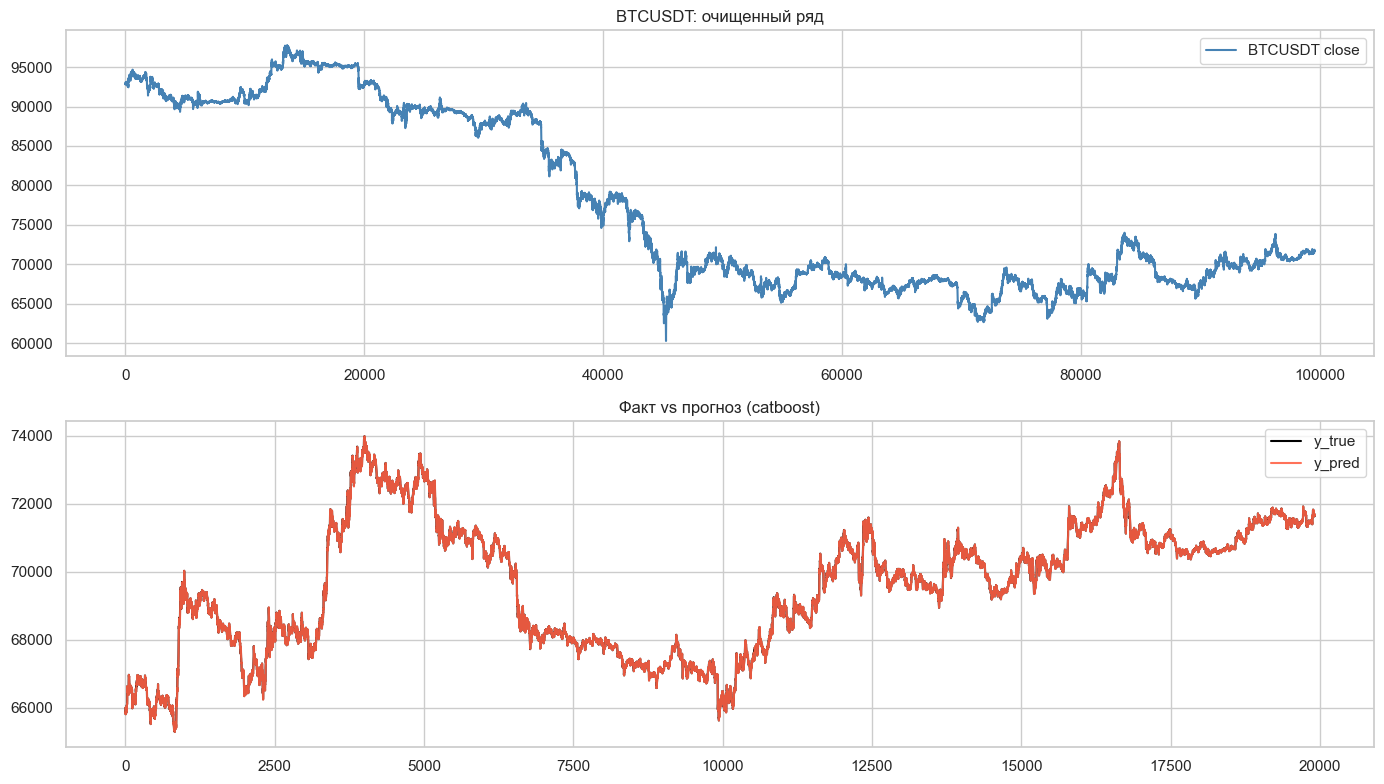

In [6]:
cache_file = Path(CATBOOST_PARAMS_CACHE_FILE)
force_recompute = bool(CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS)
cache_enabled = bool(CATBOOST_PARAMS_CACHE_ENABLED)

cache_hit = cache_enabled and cache_file.exists() and not force_recompute

if cache_hit:
    with cache_file.open('r', encoding='utf-8') as f:
        cached_payload = json.load(f)

    catboost_best_params = dict(cached_payload['best_params'])
    catboost_best_params['context_len'] = int(catboost_best_params['context_len'])
    catboost_best_params['depth'] = int(catboost_best_params['depth'])
    catboost_best_params['learning_rate'] = float(catboost_best_params['learning_rate'])
    catboost_best_params['iterations'] = int(catboost_best_params['iterations'])
    catboost_best_params['l2_leaf_reg'] = float(catboost_best_params.get('l2_leaf_reg', 3.0))
    catboost_best_params['use_cuda'] = bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA))

    catboost_cv_df = pd.DataFrame([
        {
            'cache_hit': True,
            'cached_at_utc': cached_payload.get('saved_at_utc'),
            'param_context_len': catboost_best_params['context_len'],
            'param_depth': catboost_best_params['depth'],
            'param_learning_rate': catboost_best_params['learning_rate'],
            'param_iterations': catboost_best_params['iterations'],
            'param_l2_leaf_reg': catboost_best_params['l2_leaf_reg'],
            'param_use_cuda': catboost_best_params['use_cuda'],
        }
    ])

    catboost_split_info = {
        'cache_hit': True,
        'cache_file': str(cache_file),
        'cache_saved_at_utc': cached_payload.get('saved_at_utc'),
        'search_skipped': True,
        'test_ratio': float(CONFIG.test_ratio),
        'tuning_points': int(len(tuning_full)),
    }

    print(f'CatBoost params cache HIT: {cache_file.resolve()}')
    print('Grid search skipped because cached params were found.')
else:
    catboost_best_params, catboost_cv_df, model_metrics, pred_df, catboost_split_info = run_catboost_gridsearchcv_native_pipeline(
        full_series=tuning_full,
        param_grid=CATBOOST_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=CATBOOST_CV_SPLITS,
        scoring=CATBOOST_SCORING,
        use_cuda=CATBOOST_USE_CUDA,
        n_jobs=CATBOOST_GRID_N_JOBS,
        min_resource_points=CATBOOST_SEARCH_MIN_POINTS,
        max_resource_points=CATBOOST_SEARCH_MAX_POINTS,
        halving_factor=CATBOOST_HALVING_FACTOR,
        aggressive_elimination=True,
        time_weight=CATBOOST_TIME_WEIGHT,
    )

    if cache_enabled:
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        cache_payload = {
            'saved_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'symbol': RUN_SYMBOL,
            'grid_profile': CATBOOST_GRID_PROFILE,
            'scoring': CATBOOST_SCORING,
            'best_params': catboost_best_params,
        }
        with cache_file.open('w', encoding='utf-8') as f:
            json.dump(cache_payload, f, ensure_ascii=False, indent=2)
        print(f'CatBoost params cache saved: {cache_file.resolve()}')

TRAINED_MODELS[RUN_MODEL] = fit_catboost_inference_model(
    train,
    context_len=int(catboost_best_params['context_len']),
    depth=int(catboost_best_params['depth']),
    learning_rate=float(catboost_best_params['learning_rate']),
    iterations=int(catboost_best_params['iterations']),
    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)),
)

model_metrics, pred_df = predict_catboost_inference(
    TRAINED_MODELS[RUN_MODEL],
    train=train,
    test=test,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

cv_preview_cols = [
    col for col in [
        'score',
        'score_std',
        'param_context_len',
        'param_depth',
        'param_learning_rate',
        'param_iterations',
        'param_l2_leaf_reg',
        'iter',
        'rank_test_score',
        'cache_hit',
        'cached_at_utc',
    ] if col in catboost_cv_df.columns
]

print('CatBoost tuning points:', len(tuning_full))
print('CatBoost final inference train points:', len(train))
print('CatBoost split info:', catboost_split_info)
print('CatBoost best params:', catboost_best_params)
print('CatBoost metrics:', model_metrics)
display(catboost_cv_df[cv_preview_cols].head(20) if cv_preview_cols else catboost_cv_df.head(20))
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

## 6) Backtest торговли на истории

Запускаем walk-forward backtest: выбираем старт `X` дней назад, перед каждой торговой точкой обучаем или переобучаем модель на предыдущих `40 000` minute-баров и дальше принимаем решения `long/short/close/DCA` по тем же правилам, что и в live-режиме.

В выводе отображается только журнал торговых действий.

Backtest C-entry config: horizon=180m | move_pct>=0.001%
Backtest symbol=BTCUSDT | start_days_ago=30 | duration_days=30
Train minutes=40000 | retrain_every_hours=168 | eval_step_minutes=1
Mode=long_only | initial_capital=1000.00 | entry_fraction=0.25 | execution_fee_pct=0.0600
Scenario start | mode=long_only | capital=1000.00 | entry_fraction=0.25 | fee_pct=0.0600 | retrain_every=168h | from=2026-02-13 21:05:00+00:00 | to=2026-03-15 21:05:00+00:00 | steps=43067
Retrained model | ts=2026-02-13 21:05:00+00:00 | retrain_every=168h | trade_actions=0
Trade action | ts=2026-02-13 21:06:00+00:00 | action=open_long | side=long | signal_type=enter_long_C | price=68928.1000 | qty=0.00362479 | realized_pnl=0.00 | free_cash=750.00 | invested_cash=250.00 | current_pnl=-0.15 | grid_pnl=-0.15 | equity=999.85 | reason=enter long C: forecast reached +0.001% on minute 1 within 180 minutes
Progress | date=2026-02-14 | step=500/43067 | trade_actions=1 | entry_c_hits=61/500 | free_cash=750.00 | invested_ca

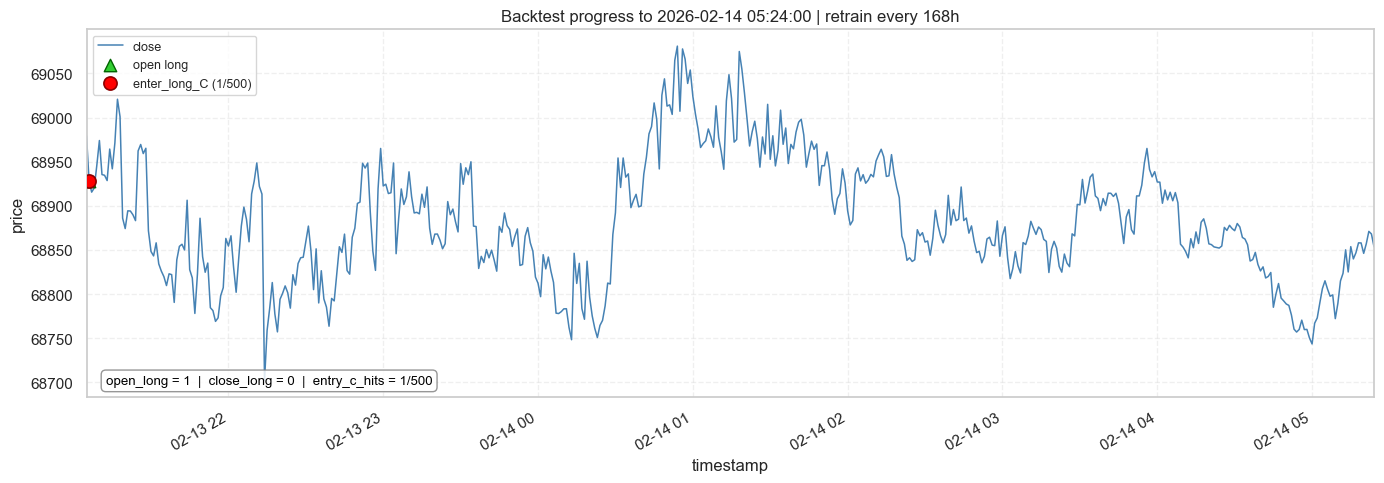

KeyboardInterrupt: 

In [ ]:
import importlib
from IPython.display import display

import catboost_backtest as _cb_backtest
_cb_backtest = importlib.reload(_cb_backtest)
BacktestConfig = _cb_backtest.BacktestConfig
run_backtest_block = _cb_backtest.run_backtest_block

BACKTEST_ENABLED = True  # Включить или выключить backtest-блок
BACKTEST_START_DAYS_AGO = 30  # За сколько дней до конца истории начинается окно теста
BACKTEST_DURATION_DAYS = 30  # Длина тестового окна в днях
BACKTEST_TRAIN_MINUTES = 40_000  # Размер обучающего окна перед каждой точкой теста
BACKTEST_RETRAIN_EVERY_HOURS = 168  # Частота переобучения модели в backtest
BACKTEST_FORCE_CPU = LIVE_FORCE_CPU  # Принудительно использовать CPU в backtest
BACKTEST_SAVE_TO_CSV = True  # Сохранять журнал действий в CSV
BACKTEST_DISPLAY_MAX_TRADES = 100  # Сколько последних действий выводить в notebook
BACKTEST_EVAL_EVERY_MINUTES = 1  # Шаг прохода по минутной истории

BACKTEST_INITIAL_CAPITAL = 1_000.0  # Стартовый виртуальный капитал в USDT
BACKTEST_ENTRY_FRACTION = 0.25  # Доля свободного капитала на одну сделку
BACKTEST_EXECUTION_FEE_PCT = float(LIVE_MAX_SIDE_FEE_PCT)  # Комиссия исполнения одной стороны сделки

BACKTEST_MIN_60M_MOVE_PCT = 0.03  # Минимальный прогнозный рост на 60 минут для входа
BACKTEST_COST_GATE_RATIO = 0.60  # Какая доля effective cost участвует в фильтре входа
BACKTEST_LONG_ENTRY_SCORE_MIN = 0.42  # Минимальный score для открытия long
BACKTEST_EXIT_SCORE_MAX = 0.08  # Если long-bias почти исчез, позицию пора закрывать
BACKTEST_COOLDOWN_MINUTES = 20  # Пауза после закрытия перед новым входом
BACKTEST_MIN_HOLD_MINUTES = 30  # Минимальное время удержания позиции
BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES = 45  # Минимальное время перед выходом по target
BACKTEST_MAX_HOLD_MINUTES = 240  # Максимальное время удержания позиции
BACKTEST_TARGET_MOVE_FLOOR_PCT = 0.18  # Нижняя граница целевого движения для фиксации прибыли
BACKTEST_SHARP_DROP_5M_PCT = 0.18  # Резкое падение на 5m для аварийного выхода из long
BACKTEST_SHARP_DROP_10M_PCT = 0.28  # Подтверждение падения на 10m для выхода из long

BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES = 180  # Горизонт поиска точки входа C
BACKTEST_ENTRY_POINT_C_MOVE_PCT = 0.001  # Порог точки C; уменьшай (например до 0.05), если входов мало

backtest_config = BacktestConfig(
    enabled=bool(BACKTEST_ENABLED),
    start_days_ago=int(BACKTEST_START_DAYS_AGO),
    duration_days=int(BACKTEST_DURATION_DAYS),
    train_minutes=int(BACKTEST_TRAIN_MINUTES),
    retrain_every_hours=int(BACKTEST_RETRAIN_EVERY_HOURS),
    force_cpu=bool(BACKTEST_FORCE_CPU),
    save_to_csv=bool(BACKTEST_SAVE_TO_CSV),
    display_max_trades=int(BACKTEST_DISPLAY_MAX_TRADES),
    eval_every_minutes=int(BACKTEST_EVAL_EVERY_MINUTES),
    initial_capital=float(BACKTEST_INITIAL_CAPITAL),
    entry_fraction=float(BACKTEST_ENTRY_FRACTION),
    execution_fee_pct=float(BACKTEST_EXECUTION_FEE_PCT),
    min_60m_move_pct=float(BACKTEST_MIN_60M_MOVE_PCT),
    cost_gate_ratio=float(BACKTEST_COST_GATE_RATIO),
    long_entry_score_min=float(BACKTEST_LONG_ENTRY_SCORE_MIN),
    exit_score_max=float(BACKTEST_EXIT_SCORE_MAX),
    cooldown_minutes=int(BACKTEST_COOLDOWN_MINUTES),
    min_hold_minutes=int(BACKTEST_MIN_HOLD_MINUTES),
    target_exit_min_hold_minutes=int(BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES),
    max_hold_minutes=int(BACKTEST_MAX_HOLD_MINUTES),
    target_move_floor_pct=float(BACKTEST_TARGET_MOVE_FLOOR_PCT),
    sharp_drop_5m_pct=float(BACKTEST_SHARP_DROP_5M_PCT),
    sharp_drop_10m_pct=float(BACKTEST_SHARP_DROP_10M_PCT),
    live_confirm_1m_pct=float(LIVE_CONFIRM_1M_PCT),
    live_entry_min_move_pct=float(LIVE_ENTRY_MIN_MOVE_PCT),
    live_stop_loss_pct=float(LIVE_STOP_LOSS_PCT),
    live_take_profit_pct=float(LIVE_TAKE_PROFIT_PCT),
    live_forecast_horizon_minutes=int(LIVE_FORECAST_HORIZON_MINUTES),
    live_signal_horizons=tuple(int(horizon) for horizon in LIVE_SIGNAL_HORIZONS),
    entry_point_c_horizon_minutes=int(BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES),
    entry_point_c_move_pct=float(BACKTEST_ENTRY_POINT_C_MOVE_PCT),
)

print(
    f"Backtest C-entry config: horizon={backtest_config.entry_point_c_horizon_minutes}m | "
    f"move_pct>={backtest_config.entry_point_c_move_pct:.3f}%"
 )

if not backtest_config.enabled:
    print('Backtest disabled (BACKTEST_ENABLED=False).')
else:
    backtest_outputs = run_backtest_block(
        history_df=cleaned_data[RUN_SYMBOL][['timestamp', 'close']].copy(),
        run_symbol=RUN_SYMBOL,
        output_dir=OUTPUT_DIR,
        catboost_best_params=catboost_best_params,
        config=backtest_config,
        compute_signal_thresholds=_compute_signal_thresholds,
        fit_catboost_inference_model=fit_catboost_inference_model,
        catboost_use_cuda=CATBOOST_USE_CUDA,
        display_fn=display,
    )

    history_df = backtest_outputs['history_df']
    backtest_results = backtest_outputs['backtest_results']
    backtest_meta_rows = backtest_outputs['backtest_meta_rows']
    BACKTEST_TRADES_DF = backtest_outputs['backtest_trades_df']
    BACKTEST_META_DF = backtest_outputs['backtest_meta_df']
    BACKTEST_TRADES_VIEW_DF = backtest_outputs['backtest_trades_view_df']
    BACKTEST_DAILY_ACTIVITY_DF = backtest_outputs['backtest_daily_activity_df']
    BACKTEST_TRADES_PATH = backtest_outputs['backtest_trades_path']

In [ ]:
if 'BACKTEST_META_DF' not in globals():
    print('Сначала запусти ячейку backtest выше.')
else:
    print('Long-only режим: показываю сводку сценария.')
    display(BACKTEST_META_DF)

In [ ]:
if 'BACKTEST_TRADES_DF' not in globals() or len(BACKTEST_TRADES_DF) == 0:
    print('Нет торговых действий для сводки.')
else:
    action_counts_df = (
        BACKTEST_TRADES_DF['action']
        .value_counts(dropna=False)
        .rename_axis('action')
        .reset_index(name='count')
    )
    display(action_counts_df)

In [ ]:
if 'BACKTEST_TRADES_DF' not in globals() or len(BACKTEST_TRADES_DF) == 0:
    print('Нет закрытых long-сделок для анализа.')
else:
    closed_trades_df = BACKTEST_TRADES_DF.loc[BACKTEST_TRADES_DF['action'] == 'close_long'].copy()
    if len(closed_trades_df) == 0:
        print('Закрытых long-сделок пока нет.')
    else:
        summary_df = pd.DataFrame([
            {'metric': 'closed_trades', 'value': int(len(closed_trades_df))},
            {'metric': 'realized_pnl_sum', 'value': float(closed_trades_df['realized_pnl'].fillna(0.0).sum())},
            {'metric': 'realized_pnl_mean', 'value': float(closed_trades_df['realized_pnl'].fillna(0.0).mean())},
            {'metric': 'win_rate', 'value': float((closed_trades_df['realized_pnl'].fillna(0.0) > 0.0).mean())},
        ])
        display(summary_df)

In [ ]:
if 'BACKTEST_TRADES_VIEW_DF' not in globals() or len(BACKTEST_TRADES_VIEW_DF) == 0:
    print('Журнал действий пуст.')
else:
    print('Последние long-only действия:')
    display(BACKTEST_TRADES_VIEW_DF.tail(30).reset_index(drop=True))

## 7) Циклический live-мониторинг CatBoost

Модель обучается на последних 40 000 minute-баров и действует 60 минут.

Логика блока:
1. каждую минуту подтягиваем актуальные данные с Bybit в SQLite,
2. если с момента последнего обучения прошло 60 минут, обучаем новую модель,
3. каждую минуту пересчитываем прогноз на 60 минут вперёд на основе текущей цены,
4. сохраняем minute-by-minute лог: реальная цена, прогноз на 1 минуту, прогноз на 60 минут,
5. когда проходит час, считаем отклонение для прогнозов, у которых наступил target timestamp.

In [ ]:
import time

from typing import Any

from IPython.display import clear_output, display

if not LIVE_MONITOR_ENABLED:

    print('Live monitor disabled (LIVE_MONITOR_ENABLED=False).')

else:

    def _prepare_minute_live_df(df: pd.DataFrame) -> pd.DataFrame:

        out = df.copy()

        out['timestamp'] = pd.to_datetime(out['timestamp'], errors='coerce', utc=True)

        out['close'] = pd.to_numeric(out['close'], errors='coerce')

        out = out.dropna(subset=['timestamp', 'close'])

        out = out[out['close'] > 0].copy()

        out = out.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

        return out[['timestamp', 'close']]



    def _forecast_catboost_path(model_obj: dict[str, Any], history_series: pd.Series, horizon: int) -> pd.DataFrame:

        history_arr = pd.to_numeric(history_series, errors='coerce').dropna().astype(float).to_numpy()

        if len(history_arr) < 10:

            raise RuntimeError('Недостаточно истории для live-прогноза.')

        context = int(model_obj['context'])

        ret_mean = float(model_obj['ret_mean'])

        ret_std = float(model_obj['ret_std'])

        model = model_obj['model']

        history_log = list(np.log(np.clip(history_arr, 1e-8, None)).astype(float))

        history_ret_norm = list(((np.diff(np.log(np.clip(history_arr, 1e-8, None))) - ret_mean) / ret_std).astype(float))

        rows = []

        for step_idx in range(int(horizon)):

            if len(history_ret_norm) >= context:

                x_ctx = np.asarray(history_ret_norm[-context:], dtype=np.float32)

            else:

                first_val = history_ret_norm[0] if len(history_ret_norm) > 0 else 0.0

                pad = np.full((context - len(history_ret_norm),), first_val, dtype=np.float32)

                x_ctx = np.concatenate([pad, np.asarray(history_ret_norm, dtype=np.float32)])

            pred_ret_norm = float(model.predict(x_ctx.reshape(1, -1))[0])

            pred_ret = pred_ret_norm * ret_std + ret_mean

            pred_ret = float(np.clip(pred_ret, -0.20, 0.20))

            pred_log = float(history_log[-1] + pred_ret)

            pred_price = float(np.exp(pred_log))

            rows.append({'step_minute': int(step_idx + 1), 'pred_price': pred_price})

            history_log.append(pred_log)

            history_ret_norm.append(pred_ret_norm)

        return pd.DataFrame(rows)



    def _calc_move_pct(predicted_price: float, current_price: float) -> float:

        if not np.isfinite(predicted_price) or not np.isfinite(current_price) or float(current_price) == 0.0:

            return float('nan')

        return float((float(predicted_price) / float(current_price) - 1.0) * 100.0)



    def _extract_horizon_forecasts(forecast_path_df: pd.DataFrame, current_price: float, horizons: list[int]) -> dict[str, float]:

        out: dict[str, float] = {}

        for horizon in horizons:

            horizon_idx = max(0, min(int(horizon) - 1, len(forecast_path_df) - 1))

            pred_price = float(forecast_path_df['pred_price'].iloc[horizon_idx])

            out[f'pred_{int(horizon)}m'] = pred_price

            out[f'move_{int(horizon)}m_pct'] = _calc_move_pct(pred_price, current_price)

        return out



    def _build_trade_signal(current_price: float, horizon_forecasts: dict[str, float]) -> dict[str, Any]:

        move_1m_pct = float(horizon_forecasts.get('move_1m_pct', float('nan')))

        move_5m_pct = float(horizon_forecasts.get('move_5m_pct', float('nan')))

        move_10m_pct = float(horizon_forecasts.get('move_10m_pct', float('nan')))

        move_15m_pct = float(horizon_forecasts.get('move_15m_pct', float('nan')))

        move_30m_pct = float(horizon_forecasts.get('move_30m_pct', float('nan')))

        move_60m_pct = float(horizon_forecasts.get('move_60m_pct', float('nan')))

        thresholds = _compute_signal_thresholds(horizon_forecasts)
        forecast_scale_pct = float(thresholds['forecast_scale_pct'])
        required_move_pct = float(thresholds['required_move_pct'])
        effective_cost_pct = float(thresholds['effective_cost_pct'])
        entry_trigger_move_pct = float(thresholds['entry_trigger_move_pct'])
        adaptive_pullback_pct = float(thresholds['adaptive_pullback_pct'])
        adaptive_reversal_pct = float(thresholds['adaptive_reversal_pct'])

        long_edge_pct = float(move_60m_pct - effective_cost_pct)
        short_edge_pct = float((-move_60m_pct) - effective_cost_pct)

        signal = 'hold'

        signal_type = 'none'

        entry_price = float(current_price)

        stop_loss = float('nan')

        take_profit = float('nan')

        target_exit_price = float('nan')

        reason = f'adaptive edge below threshold: |move_60m| < {entry_trigger_move_pct:.3f}%'

        if all(np.isfinite(v) for v in [move_1m_pct, move_5m_pct, move_10m_pct, move_30m_pct, move_60m_pct]):

            trend_long = (
                move_60m_pct >= entry_trigger_move_pct
                and long_edge_pct >= 0.0
                and move_5m_pct >= 0.0
                and move_10m_pct >= LIVE_CONFIRM_1M_PCT
                and move_30m_pct > 0.0
            )

            trend_short = (
                (-move_60m_pct) >= entry_trigger_move_pct
                and short_edge_pct >= 0.0
                and move_5m_pct <= 0.0
                and move_10m_pct <= -LIVE_CONFIRM_1M_PCT
                and move_30m_pct < 0.0
            )

            dip_long = (
                move_60m_pct >= entry_trigger_move_pct
                and long_edge_pct >= 0.0
                and move_5m_pct <= -adaptive_pullback_pct
                and move_10m_pct >= adaptive_reversal_pct
                and move_30m_pct > 0.0
                and move_60m_pct > 0.0
            )

            rally_short = (
                (-move_60m_pct) >= entry_trigger_move_pct
                and short_edge_pct >= 0.0
                and move_5m_pct >= adaptive_pullback_pct
                and move_10m_pct <= -adaptive_reversal_pct
                and move_30m_pct < 0.0
                and move_60m_pct < 0.0
            )

            if dip_long:

                signal = 'long'

                signal_type = 'buy_dip'

                stop_loss = float(current_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive buy_dip: 5m pullback with 10m/30m/60m recovery'

            elif rally_short:

                signal = 'short'

                signal_type = 'sell_rally'

                stop_loss = float(current_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive sell_rally: 5m rally with 10m/30m/60m decline'

            elif trend_long:

                signal = 'long'

                signal_type = 'trend_long'

                stop_loss = float(current_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive trend_long: 10m/30m/60m aligned upward'

            elif trend_short:

                signal = 'short'

                signal_type = 'trend_short'

                stop_loss = float(current_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive trend_short: 10m/30m/60m aligned downward'

            else:

                reason = 'adaptive threshold passed partly, but path is not aligned for entry' if max(abs(move_60m_pct), 0.0) >= entry_trigger_move_pct else reason

        return {
            'signal': signal,
            'signal_type': signal_type,
            'entry_price': entry_price,
            'move_1m_pct': move_1m_pct,
            'move_5m_pct': move_5m_pct,
            'move_10m_pct': move_10m_pct,
            'move_15m_pct': move_15m_pct,
            'move_30m_pct': move_30m_pct,
            'move_60m_pct': move_60m_pct,
            'forecast_scale_pct': forecast_scale_pct,
            'required_move_pct': required_move_pct,
            'effective_cost_pct': effective_cost_pct,
            'entry_trigger_move_pct': entry_trigger_move_pct,
            'adaptive_pullback_pct': adaptive_pullback_pct,
            'adaptive_reversal_pct': adaptive_reversal_pct,
            'long_edge_pct': float(long_edge_pct),
            'short_edge_pct': float(short_edge_pct),
            'stop_loss': stop_loss,
            'take_profit': take_profit,
            'target_exit_price': target_exit_price,
            'reason': reason,
        }



    def _load_live_history(symbol: str, history_limit: int) -> tuple[pd.DataFrame, dict[str, Any] | None]:

        live_history_bars = int(history_limit + LIVE_FORECAST_HORIZON_MINUTES + LIVE_SYNC_BUFFER)

        live_config = DataConfig(
            base_url=CONFIG.base_url,
            interval='1',
            bars=live_history_bars,
            target_col=CONFIG.target_col,
            date_col=CONFIG.date_col,
            test_ratio=CONFIG.test_ratio,
        )

        _, live_snapshot = sync_market_data_to_sqlite(
            symbol=symbol,
            config=live_config,
            db_path=SQLITE_DB_PATH,
            history_bars=live_history_bars,
            fetch_snapshot=True,
        )

        live_raw = load_klines_from_sqlite(
            symbol=symbol,
            interval='1',
            db_path=SQLITE_DB_PATH,
            limit=live_history_bars,
        )

        live_df = _prepare_minute_live_df(live_raw)

        return live_df, live_snapshot



    def _position_unrealized_pnl(position: dict[str, Any] | None, current_price: float) -> float:

        if position is None:

            return 0.0

        qty = float(position['qty'])

        avg_entry = float(position['avg_entry_price'])

        if position['side'] == 'long':

            return float((current_price - avg_entry) * qty)

        return float((avg_entry - current_price) * qty)



    def _position_return_pct(position: dict[str, Any] | None, current_price: float) -> float:

        if position is None or float(position['avg_entry_price']) == 0.0:

            return float('nan')

        if position['side'] == 'long':

            return float((current_price / float(position['avg_entry_price']) - 1.0) * 100.0)

        return float((float(position['avg_entry_price']) / current_price - 1.0) * 100.0)



    def _position_levels(side: str, avg_entry_price: float) -> tuple[float, float]:

        if side == 'long':

            return (
                float(avg_entry_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0)),
                float(avg_entry_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0)),
            )

        return (
            float(avg_entry_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0)),
            float(avg_entry_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0)),
        )



    def _open_position(side: str, signal_type: str, current_price: float, current_ts: pd.Timestamp, target_exit_price: float, free_cash: float, fraction: float) -> dict[str, Any] | None:

        allocation_cash = float(min(free_cash, max(0.0, free_cash * float(fraction))))

        if allocation_cash <= 0.0 or current_price <= 0.0:

            return None

        qty = float((allocation_cash * PAPER_LEVERAGE) / current_price)

        stop_loss, take_profit = _position_levels(side, current_price)

        return {
            'side': side,
            'signal_type': signal_type,
            'opened_at': current_ts,
            'planned_exit_ts': current_ts + pd.Timedelta(minutes=LIVE_FORECAST_HORIZON_MINUTES),
            'avg_entry_price': float(current_price),
            'qty': qty,
            'margin_used': allocation_cash,
            'notional': float(qty * current_price),
            'dca_count': 0,
            'target_exit_price': float(target_exit_price),
            'stop_loss': float(stop_loss),
            'take_profit': float(take_profit),
            'entries': [
                {
                    'ts': current_ts,
                    'price': float(current_price),
                    'cash': allocation_cash,
                    'qty': qty,
                    'reason': 'initial_entry',
                }
            ],
        }



    def _add_to_position(position: dict[str, Any], current_price: float, current_ts: pd.Timestamp, free_cash: float, fraction: float, target_exit_price: float) -> tuple[dict[str, Any], float] | tuple[None, float]:

        allocation_cash = float(min(free_cash, max(0.0, free_cash * float(fraction))))

        if allocation_cash <= 0.0 or current_price <= 0.0:

            return None, 0.0

        add_qty = float((allocation_cash * PAPER_LEVERAGE) / current_price)

        new_qty = float(position['qty'] + add_qty)

        if new_qty <= 0.0:

            return None, 0.0

        new_avg = float((position['qty'] * position['avg_entry_price'] + add_qty * current_price) / new_qty)

        position['qty'] = new_qty

        position['avg_entry_price'] = new_avg

        position['margin_used'] = float(position['margin_used'] + allocation_cash)

        position['notional'] = float(position['qty'] * current_price)

        position['dca_count'] = int(position['dca_count'] + 1)

        if position['side'] == 'long':

            position['target_exit_price'] = float(max(position['target_exit_price'], target_exit_price)) if np.isfinite(target_exit_price) else float(position['target_exit_price'])

        else:

            position['target_exit_price'] = float(min(position['target_exit_price'], target_exit_price)) if np.isfinite(target_exit_price) else float(position['target_exit_price'])

        stop_loss, take_profit = _position_levels(position['side'], new_avg)

        position['stop_loss'] = float(stop_loss)

        position['take_profit'] = float(take_profit)

        position['entries'].append({
            'ts': current_ts,
            'price': float(current_price),
            'cash': allocation_cash,
            'qty': add_qty,
            'reason': f'dca_{position["dca_count"]}',
        })

        return position, allocation_cash



    def _close_position(position: dict[str, Any], current_price: float, current_ts: pd.Timestamp, reason: str) -> tuple[float, dict[str, Any]]:

        unrealized_pnl = _position_unrealized_pnl(position, current_price)

        released_cash = float(position['margin_used'] + unrealized_pnl)

        trade = {
            'side': position['side'],
            'signal_type': position['signal_type'],
            'opened_at': position['opened_at'],
            'closed_at': current_ts,
            'avg_entry_price': float(position['avg_entry_price']),
            'exit_price': float(current_price),
            'target_exit_price': float(position['target_exit_price']),
            'qty': float(position['qty']),
            'margin_used': float(position['margin_used']),
            'realized_pnl': float(unrealized_pnl),
            'return_pct': float(_position_return_pct(position, current_price)),
            'dca_count': int(position['dca_count']),
            'close_reason': reason,
        }

        return released_cash, trade



    def _should_dca(position: dict[str, Any] | None, signal: dict[str, Any], current_price: float) -> bool:

        if position is None or signal['signal'] != position['side']:

            return False

        if int(position['dca_count']) >= int(PAPER_MAX_DCA_COUNT):

            return False

        avg_entry = float(position['avg_entry_price'])

        step_threshold = float(PAPER_DCA_STEP_PCT * (int(position['dca_count']) + 1))

        if position['side'] == 'long':

            adverse_move_pct = float((current_price / avg_entry - 1.0) * 100.0)

            return adverse_move_pct <= -step_threshold

        adverse_move_pct = float((current_price / avg_entry - 1.0) * 100.0)

        return adverse_move_pct >= step_threshold



    forecast_journal = []

    live_rows = []

    active_model = None

    cycle_idx = 0

    paper_state = {
        'enabled': bool(PAPER_TRADING_ENABLED),
        'free_cash': float(PAPER_INITIAL_CAPITAL),
        'realized_pnl': 0.0,
        'position': None,
        'closed_trades': [],
    }

    try:

        while LIVE_MAX_CYCLES is None or cycle_idx < int(LIVE_MAX_CYCLES):

            cycle_idx += 1

            fit_started = False

            live_df, live_snapshot = _load_live_history(RUN_SYMBOL, LIVE_TRAIN_MINUTES)

            if len(live_df) < LIVE_TRAIN_MINUTES:

                raise RuntimeError(
                    f'Недостаточно данных для live-train: {len(live_df)} < {LIVE_TRAIN_MINUTES}. '
                    'Увеличь историю в SQLite или уменьши LIVE_TRAIN_MINUTES.'
                )

            current_ts = pd.Timestamp(live_df['timestamp'].iloc[-1]).floor('min')

            current_price = float(live_df['close'].iloc[-1])

            train_df = live_df.iloc[-LIVE_TRAIN_MINUTES:].reset_index(drop=True)

            train_series = train_df['close'].astype(float).reset_index(drop=True)

            needs_refit = active_model is None or current_ts >= active_model['expires_at']

            if needs_refit:

                fit_t0 = time.perf_counter()

                model_obj = fit_catboost_inference_model(
                    train_series,
                    context_len=int(catboost_best_params['context_len']),
                    depth=int(catboost_best_params['depth']),
                    learning_rate=float(catboost_best_params['learning_rate']),
                    iterations=int(catboost_best_params['iterations']),
                    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
                    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)) and not LIVE_FORCE_CPU,
                )

                fit_sec = float(time.perf_counter() - fit_t0)

                active_model = {
                    'model_obj': model_obj,
                    'fitted_at': current_ts,
                    'expires_at': current_ts + pd.Timedelta(minutes=LIVE_RETRAIN_EVERY_MINUTES),
                    'fit_sec': fit_sec,
                    'train_start_ts': pd.Timestamp(train_df['timestamp'].iloc[0]),
                    'train_end_ts': pd.Timestamp(train_df['timestamp'].iloc[-1]),
                }

                fit_started = True

            forecast_path_df = _forecast_catboost_path(
                active_model['model_obj'],
                history_series=train_series,
                horizon=int(LIVE_FORECAST_HORIZON_MINUTES),
            )
            forecast_path_df = forecast_path_df.copy()
            forecast_path_df['origin_ts'] = current_ts
            forecast_path_df['target_ts'] = forecast_path_df['step_minute'].map(
                lambda minute: current_ts + pd.Timedelta(minutes=int(minute))
            )
            forecast_path_df['current_price'] = float(current_price)
            forecast_path_df['move_pct'] = forecast_path_df['pred_price'].map(
                lambda price: _calc_move_pct(price, current_price)
            )

            next_minute_pred = float(forecast_path_df.loc[forecast_path_df['step_minute'] == 1, 'pred_price'].iloc[0])

            hour_pred = float(forecast_path_df.loc[forecast_path_df['step_minute'] == int(LIVE_FORECAST_HORIZON_MINUTES), 'pred_price'].iloc[0])

            horizon_forecasts = _extract_horizon_forecasts(
                forecast_path_df=forecast_path_df,
                current_price=current_price,
                horizons=[int(h) for h in LIVE_SIGNAL_HORIZONS],
            )

            trade_signal = _build_trade_signal(
                current_price=current_price,
                horizon_forecasts=horizon_forecasts,
            )

            if paper_state['enabled']:

                position = paper_state['position']

                if position is not None:

                    close_reason = None

                    if position['side'] == 'long':

                        if current_price <= float(position['stop_loss']):

                            close_reason = 'stop_loss'

                        elif current_price >= float(position['take_profit']):

                            close_reason = 'take_profit'

                        elif np.isfinite(position['target_exit_price']) and current_price >= float(position['target_exit_price']):

                            close_reason = 'target_exit_price'

                    else:

                        if current_price >= float(position['stop_loss']):

                            close_reason = 'stop_loss'

                        elif current_price <= float(position['take_profit']):

                            close_reason = 'take_profit'

                        elif np.isfinite(position['target_exit_price']) and current_price <= float(position['target_exit_price']):

                            close_reason = 'target_exit_price'

                    if close_reason is None and PAPER_CLOSE_ON_SIGNAL_FLIP and trade_signal['signal'] in {'long', 'short'} and trade_signal['signal'] != position['side']:

                        close_reason = 'signal_flip'

                    if close_reason is None and PAPER_CLOSE_ON_MODEL_EXPIRY and current_ts >= pd.Timestamp(position['planned_exit_ts']):

                        close_reason = 'planned_exit_ts'

                    if close_reason is not None:

                        released_cash, closed_trade = _close_position(position, current_price, current_ts, close_reason)

                        paper_state['free_cash'] = float(paper_state['free_cash'] + released_cash)

                        paper_state['realized_pnl'] = float(paper_state['realized_pnl'] + closed_trade['realized_pnl'])

                        paper_state['closed_trades'].append(closed_trade)

                        paper_state['position'] = None

                        position = None

                if paper_state['position'] is None and trade_signal['signal'] in {'long', 'short'}:

                    new_position = _open_position(
                        side=trade_signal['signal'],
                        signal_type=trade_signal['signal_type'],
                        current_price=current_price,
                        current_ts=current_ts,
                        target_exit_price=float(trade_signal['target_exit_price']),
                        free_cash=float(paper_state['free_cash']),
                        fraction=float(PAPER_ENTRY_FRACTION),
                    )

                    if new_position is not None:

                        paper_state['free_cash'] = float(paper_state['free_cash'] - new_position['margin_used'])

                        paper_state['position'] = new_position

                elif paper_state['position'] is not None and _should_dca(paper_state['position'], trade_signal, current_price):

                    updated_position, added_cash = _add_to_position(
                        position=paper_state['position'],
                        current_price=current_price,
                        current_ts=current_ts,
                        free_cash=float(paper_state['free_cash']),
                        fraction=float(PAPER_DCA_FRACTION),
                        target_exit_price=float(trade_signal['target_exit_price']),
                    )

                    if updated_position is not None and added_cash > 0.0:

                        paper_state['free_cash'] = float(paper_state['free_cash'] - added_cash)

                        paper_state['position'] = updated_position

            forecast_target_ts = current_ts + pd.Timedelta(minutes=LIVE_FORECAST_HORIZON_MINUTES)

            forecast_journal.append({
                'origin_ts': current_ts,
                'target_ts': forecast_target_ts,
                'predicted_price_1m': next_minute_pred,
                'predicted_price_5m': float(horizon_forecasts.get('pred_5m', float('nan'))),
                'predicted_price_10m': float(horizon_forecasts.get('pred_10m', float('nan'))),
                'predicted_price_15m': float(horizon_forecasts.get('pred_15m', float('nan'))),
                'predicted_price_30m': float(horizon_forecasts.get('pred_30m', float('nan'))),
                'predicted_price_60m': hour_pred,
                'move_1m_pct': trade_signal['move_1m_pct'],
                'move_5m_pct': trade_signal['move_5m_pct'],
                'move_10m_pct': trade_signal['move_10m_pct'],
                'move_15m_pct': trade_signal['move_15m_pct'],
                'move_30m_pct': trade_signal['move_30m_pct'],
                'move_60m_pct': trade_signal['move_60m_pct'],
                'signal': trade_signal['signal'],
                'signal_type': trade_signal['signal_type'],
                'entry_price': trade_signal['entry_price'],
                'target_exit_price': trade_signal['target_exit_price'],
                'stop_loss': trade_signal['stop_loss'],
                'take_profit': trade_signal['take_profit'],
                'signal_reason': trade_signal['reason'],
                'model_fitted_at': active_model['fitted_at'],
                'model_expires_at': active_model['expires_at'],
                'evaluated': False,
            })

            matured_rows = []

            for row in forecast_journal:

                if row['evaluated'] or pd.Timestamp(row['target_ts']) > current_ts:

                    continue

                actual_match = live_df.loc[live_df['timestamp'] == pd.Timestamp(row['target_ts']), 'close']

                if len(actual_match) == 0:

                    continue

                actual_price_60m = float(actual_match.iloc[-1])

                row['actual_price_60m'] = actual_price_60m

                row['error_abs_60m'] = float(abs(actual_price_60m - row['predicted_price_60m']))

                row['error_pct_60m'] = float((actual_price_60m / row['predicted_price_60m'] - 1.0) * 100.0) if row['predicted_price_60m'] != 0 else float('nan')

                row['evaluated'] = True

                matured_rows.append({
                    'target_ts': row['target_ts'],
                    'signal': row['signal'],
                    'signal_type': row['signal_type'],
                    'pred_60m': row['predicted_price_60m'],
                    'actual_60m': actual_price_60m,
                    'abs_err_60m': row['error_abs_60m'],
                    'pct_err_60m': row['error_pct_60m'],
                })

            position = paper_state['position'] if paper_state['enabled'] else None
            unrealized_pnl = _position_unrealized_pnl(position, current_price)
            account_equity = float(paper_state['free_cash'] + (position['margin_used'] if position is not None else 0.0) + unrealized_pnl) if paper_state['enabled'] else float('nan')

            snapshot_last_price = float(live_snapshot['last_price']) if live_snapshot is not None and pd.notna(live_snapshot.get('last_price', np.nan)) else current_price

            live_rows.append({
                'cycle': int(cycle_idx),
                'timestamp': current_ts,
                'current_price': current_price,
                'snapshot_last_price': snapshot_last_price,
                'predicted_price_1m': next_minute_pred,
                'predicted_price_5m': float(horizon_forecasts.get('pred_5m', float('nan'))),
                'predicted_price_10m': float(horizon_forecasts.get('pred_10m', float('nan'))),
                'predicted_price_15m': float(horizon_forecasts.get('pred_15m', float('nan'))),
                'predicted_price_30m': float(horizon_forecasts.get('pred_30m', float('nan'))),
                'predicted_price_60m': hour_pred,
                'move_1m_pct': float(trade_signal['move_1m_pct']),
                'move_5m_pct': float(trade_signal['move_5m_pct']),
                'move_10m_pct': float(trade_signal['move_10m_pct']),
                'move_15m_pct': float(trade_signal['move_15m_pct']),
                'move_30m_pct': float(trade_signal['move_30m_pct']),
                'move_60m_pct': float(trade_signal['move_60m_pct']),
                'signal': trade_signal['signal'],
                'signal_type': trade_signal['signal_type'],
                'entry_price': float(trade_signal['entry_price']),
                'target_exit_price': float(trade_signal['target_exit_price']),
                'stop_loss': float(trade_signal['stop_loss']),
                'take_profit': float(trade_signal['take_profit']),
                'signal_reason': trade_signal['reason'],
                'position_side': position['side'] if position is not None else 'flat',
                'position_avg_entry': float(position['avg_entry_price']) if position is not None else float('nan'),
                'position_qty': float(position['qty']) if position is not None else 0.0,
                'position_target_exit': float(position['target_exit_price']) if position is not None else float('nan'),
                'position_stop_loss': float(position['stop_loss']) if position is not None else float('nan'),
                'position_take_profit': float(position['take_profit']) if position is not None else float('nan'),
                'position_dca_count': int(position['dca_count']) if position is not None else 0,
                'position_unrealized_pnl': float(unrealized_pnl),
                'position_return_pct': float(_position_return_pct(position, current_price)) if position is not None else float('nan'),
                'free_cash': float(paper_state['free_cash']) if paper_state['enabled'] else float('nan'),
                'realized_pnl_total': float(paper_state['realized_pnl']) if paper_state['enabled'] else float('nan'),
                'account_equity': float(account_equity),
                'model_fitted_at': active_model['fitted_at'],
                'model_expires_at': active_model['expires_at'],
                'fit_triggered': bool(fit_started),
                'fit_sec': float(active_model['fit_sec']),
                'matured_60m_count': int(len(matured_rows)),
                'latest_abs_err_60m': float(matured_rows[-1]['abs_err_60m']) if len(matured_rows) > 0 else float('nan'),
                'latest_pct_err_60m': float(matured_rows[-1]['pct_err_60m']) if len(matured_rows) > 0 else float('nan'),
            })

            live_monitor_df = pd.DataFrame(live_rows)
            matured_df = pd.DataFrame([row for row in forecast_journal if row.get('evaluated')])
            paper_trades_df = pd.DataFrame(paper_state['closed_trades'])
            position_df = pd.DataFrame([position]) if position is not None else pd.DataFrame()
            LIVE_LAST_FORECAST_PATH_DF = forecast_path_df.copy()

            clear_output(wait=True)

            print(
                f'Cycle {cycle_idx} | now={current_ts} | current={current_price:.4f} | '
                f'pred+5m={float(horizon_forecasts.get("pred_5m", float("nan"))):.4f} | '
                f'pred+10m={float(horizon_forecasts.get("pred_10m", float("nan"))):.4f} | '
                f'pred+60m={hour_pred:.4f} | signal={trade_signal["signal"]}/{trade_signal["signal_type"]}'
            )

            print(
                f'Entry plan={trade_signal["entry_price"]:.4f} | target_exit={trade_signal["target_exit_price"]:.4f} | '
                f'stop={trade_signal["stop_loss"]:.4f} | tp={trade_signal["take_profit"]:.4f} | reason={trade_signal["reason"]}'
            )

            print(
                f'Model fitted_at={active_model["fitted_at"]} | expires_at={active_model["expires_at"]} | '
                f'fit_triggered={fit_started} | fit_sec={active_model["fit_sec"]:.2f}'
            )

            if live_snapshot is not None:

                print(
                    f'Snapshot: last={float(live_snapshot["last_price"]):.4f} | '
                    f'bid={float(live_snapshot["bid_price"]):.4f} | ask={float(live_snapshot["ask_price"]):.4f}'
                )

            if paper_state['enabled']:

                print(
                    f'Paper x{PAPER_LEVERAGE:.0f}: free_cash={paper_state["free_cash"]:.2f} | '
                    f'realized_pnl={paper_state["realized_pnl"]:.2f} | equity={account_equity:.2f}'
                )

            print('\nMinute-by-minute log:')
            display(live_monitor_df.tail(10))

            print('\nForecast path for each minute ahead:')
            display(forecast_path_df[['step_minute', 'target_ts', 'pred_price', 'move_pct']].head(60))

            if len(position_df) > 0:

                print('\nActive paper position:')
                display(position_df)

            if len(paper_trades_df) > 0:

                print('\nClosed paper trades:')
                display(paper_trades_df.tail(10))

            if len(matured_df) > 0:

                matured_view = matured_df[['origin_ts', 'target_ts', 'signal', 'signal_type', 'predicted_price_60m', 'actual_price_60m', 'error_abs_60m', 'error_pct_60m']].tail(10).copy()

                print('\nClosed 60-minute forecasts:')
                display(matured_view)

            next_poll_ts = pd.Timestamp.now(tz='UTC') + pd.Timedelta(seconds=LIVE_POLL_SECONDS)
            print(f'Next refresh after ~{LIVE_POLL_SECONDS} sec at {next_poll_ts}. Stop cell manually to exit.')
            time.sleep(max(1, int(LIVE_POLL_SECONDS)))

    except KeyboardInterrupt:

        print('Live monitoring stopped by user.')

    LIVE_MONITOR_DF = pd.DataFrame(live_rows)
    LIVE_FORECAST_JOURNAL_DF = pd.DataFrame(forecast_journal)
    PAPER_TRADES_DF = pd.DataFrame(paper_state['closed_trades']) if paper_state['enabled'] else pd.DataFrame()

    live_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')
    live_detail_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_live_monitor_{live_ts}.csv"
    live_forecast_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_live_forecasts_{live_ts}.csv"
    paper_trades_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_paper_trades_{live_ts}.csv"

    LIVE_MONITOR_DF.to_csv(live_detail_path, index=False)
    LIVE_FORECAST_JOURNAL_DF.to_csv(live_forecast_path, index=False)
    PAPER_TRADES_DF.to_csv(paper_trades_path, index=False)

    print('\nSaved live logs:')
    print(live_detail_path.resolve())
    print(live_forecast_path.resolve())
    print(paper_trades_path.resolve())

    if len(LIVE_MONITOR_DF) > 0:
        display(LIVE_MONITOR_DF.tail(20))

    if 'LIVE_LAST_FORECAST_PATH_DF' in globals() and len(LIVE_LAST_FORECAST_PATH_DF) > 0:
        display(LIVE_LAST_FORECAST_PATH_DF[['step_minute', 'target_ts', 'pred_price', 'move_pct']].head(60))

    if len(PAPER_TRADES_DF) > 0:
        display(PAPER_TRADES_DF.tail(20))

    if len(LIVE_FORECAST_JOURNAL_DF) > 0:
        display(LIVE_FORECAST_JOURNAL_DF.tail(20))

Cycle 2 | now=2026-03-11 15:32:00+00:00 | current=69681.9000 | pred+5m=69694.4827 | pred+10m=69699.9306 | pred+60m=69713.7257 | signal=long/trend_long
Entry plan=69681.9000 | target_exit=69713.7257 | stop=69438.0133 | tp=70099.9914 | reason=adaptive trend_long: 10m/30m/60m aligned upward
Model fitted_at=2026-03-11 15:31:00+00:00 | expires_at=2026-03-11 16:31:00+00:00 | fit_triggered=False | fit_sec=1.15
Snapshot: last=69677.7000 | bid=69687.4000 | ask=69687.5000
Paper x1: free_cash=9000.00 | realized_pnl=0.00 | equity=10000.00

Minute-by-minute log:


,cycle,timestamp,current_price,snapshot_last_price,predicted_price_1m,predicted_price_5m,predicted_price_10m,predicted_price_15m,predicted_price_30m,predicted_price_60m,move_1m_pct,move_5m_pct,move_10m_pct,move_15m_pct,move_30m_pct,move_60m_pct,signal,signal_type,entry_price,target_exit_price,stop_loss,take_profit,signal_reason,position_side,position_avg_entry,position_qty,position_target_exit,position_stop_loss,position_take_profit,position_dca_count,position_unrealized_pnl,position_return_pct,free_cash,realized_pnl_total,account_equity,model_fitted_at,model_expires_at,fit_triggered,fit_sec,matured_60m_count,latest_abs_err_60m,latest_pct_err_60m
0,1,2026-03-11 15:31:00+00:00,69852.2,69850.0,69850.478800,69856.099361,69853.071434,69869.465681,69859.511036,69867.700376,-0.002464,0.005582,0.001248,0.024717,0.010466,0.022190,hold,none,69852.2,NaN,NaN,NaN,adaptive edge below threshold: |move_60m| < 0....,flat,NaN,0.000000,NaN,NaN,NaN,0,0.0,NaN,10000.0,0.0,10000.0,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,True,1.148607,0,NaN,NaN
1,2,2026-03-11 15:32:00+00:00,69681.9,69677.7,69682.804552,69694.482677,69699.930606,69715.091744,69710.497924,69713.725682,0.001298,0.018057,0.025876,0.047633,0.041041,0.045673,long,trend_long,69681.9,69713.725682,69438.01335,70099.9914,adaptive trend_long: 10m/30m/60m aligned upward,long,69681.9,0.014351,69713.725682,69438.01335,70099.9914,0,0.0,0.0,9000.0,0.0,10000.0,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,False,1.148607,0,NaN,NaN



Forecast path for each minute ahead:


,step_minute,target_ts,pred_price,move_pct
0,1,2026-03-11 15:33:00+00:00,69682.804552,0.001298
1,2,2026-03-11 15:34:00+00:00,69685.549664,0.005238
2,3,2026-03-11 15:35:00+00:00,69691.940640,0.014409
3,4,2026-03-11 15:36:00+00:00,69693.961555,0.017309
4,5,2026-03-11 15:37:00+00:00,69694.482677,0.018057
5,6,2026-03-11 15:38:00+00:00,69692.916278,0.015809
6,7,2026-03-11 15:39:00+00:00,69691.262699,0.013436
7,8,2026-03-11 15:40:00+00:00,69696.604718,0.021103
8,9,2026-03-11 15:41:00+00:00,69694.265049,0.017745
9,10,2026-03-11 15:42:00+00:00,69699.930606,0.025876



Active paper position:


,side,signal_type,opened_at,planned_exit_ts,avg_entry_price,qty,margin_used,notional,dca_count,target_exit_price,stop_loss,take_profit,entries
0,long,trend_long,2026-03-11 15:32:00+00:00,2026-03-11 16:32:00+00:00,69681.9,0.014351,1000.0,1000.0,0,69713.725682,69438.01335,70099.9914,"[{'ts': 2026-03-11 15:32:00+00:00, 'price': 69..."


Next refresh after ~60 sec at 2026-03-11 15:33:13.801292+00:00. Stop cell manually to exit.
Live monitoring stopped by user.

Saved live logs:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_live_monitor_20260311_153313.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_live_forecasts_20260311_153313.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_paper_trades_20260311_153313.csv


,cycle,timestamp,current_price,snapshot_last_price,predicted_price_1m,predicted_price_5m,predicted_price_10m,predicted_price_15m,predicted_price_30m,predicted_price_60m,move_1m_pct,move_5m_pct,move_10m_pct,move_15m_pct,move_30m_pct,move_60m_pct,signal,signal_type,entry_price,target_exit_price,stop_loss,take_profit,signal_reason,position_side,position_avg_entry,position_qty,position_target_exit,position_stop_loss,position_take_profit,position_dca_count,position_unrealized_pnl,position_return_pct,free_cash,realized_pnl_total,account_equity,model_fitted_at,model_expires_at,fit_triggered,fit_sec,matured_60m_count,latest_abs_err_60m,latest_pct_err_60m
0,1,2026-03-11 15:31:00+00:00,69852.2,69850.0,69850.478800,69856.099361,69853.071434,69869.465681,69859.511036,69867.700376,-0.002464,0.005582,0.001248,0.024717,0.010466,0.022190,hold,none,69852.2,NaN,NaN,NaN,adaptive edge below threshold: |move_60m| < 0....,flat,NaN,0.000000,NaN,NaN,NaN,0,0.0,NaN,10000.0,0.0,10000.0,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,True,1.148607,0,NaN,NaN
1,2,2026-03-11 15:32:00+00:00,69681.9,69677.7,69682.804552,69694.482677,69699.930606,69715.091744,69710.497924,69713.725682,0.001298,0.018057,0.025876,0.047633,0.041041,0.045673,long,trend_long,69681.9,69713.725682,69438.01335,70099.9914,adaptive trend_long: 10m/30m/60m aligned upward,long,69681.9,0.014351,69713.725682,69438.01335,70099.9914,0,0.0,0.0,9000.0,0.0,10000.0,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,False,1.148607,0,NaN,NaN


,step_minute,target_ts,pred_price,move_pct
0,1,2026-03-11 15:33:00+00:00,69682.804552,0.001298
1,2,2026-03-11 15:34:00+00:00,69685.549664,0.005238
2,3,2026-03-11 15:35:00+00:00,69691.940640,0.014409
3,4,2026-03-11 15:36:00+00:00,69693.961555,0.017309
4,5,2026-03-11 15:37:00+00:00,69694.482677,0.018057
5,6,2026-03-11 15:38:00+00:00,69692.916278,0.015809
6,7,2026-03-11 15:39:00+00:00,69691.262699,0.013436
7,8,2026-03-11 15:40:00+00:00,69696.604718,0.021103
8,9,2026-03-11 15:41:00+00:00,69694.265049,0.017745
9,10,2026-03-11 15:42:00+00:00,69699.930606,0.025876


,origin_ts,target_ts,predicted_price_1m,predicted_price_5m,predicted_price_10m,predicted_price_15m,predicted_price_30m,predicted_price_60m,move_1m_pct,move_5m_pct,move_10m_pct,move_15m_pct,move_30m_pct,move_60m_pct,signal,signal_type,entry_price,target_exit_price,stop_loss,take_profit,signal_reason,model_fitted_at,model_expires_at,evaluated
0,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,69850.478800,69856.099361,69853.071434,69869.465681,69859.511036,69867.700376,-0.002464,0.005582,0.001248,0.024717,0.010466,0.022190,hold,none,69852.2,NaN,NaN,NaN,adaptive edge below threshold: |move_60m| < 0....,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,False
1,2026-03-11 15:32:00+00:00,2026-03-11 16:32:00+00:00,69682.804552,69694.482677,69699.930606,69715.091744,69710.497924,69713.725682,0.001298,0.018057,0.025876,0.047633,0.041041,0.045673,long,trend_long,69681.9,69713.725682,69438.01335,70099.9914,adaptive trend_long: 10m/30m/60m aligned upward,2026-03-11 15:31:00+00:00,2026-03-11 16:31:00+00:00,False


## 8) Summary по backtest

Сводка считает метрики по закрытым сделкам и сравнивает сценарии переобучения модели, например каждые `24` и `168` часов.

Базовые метрики: количество закрытых сделок, winrate, суммарный PnL, ending equity.

Дополнительно: средний PnL на сделку, gross profit, gross loss и profit factor.

In [ ]:
if 'BACKTEST_DAILY_ACTIVITY_DF' not in globals() or len(BACKTEST_DAILY_ACTIVITY_DF) == 0:
    print('Нет дневной активности для отображения.')
else:
    print('Дневная активность long-only backtest:')
    display(BACKTEST_DAILY_ACTIVITY_DF.tail(30).reset_index(drop=True))

Backtest summary ready.
Best scenario: retrain_every=168h | closed_trades=23 | winrate=30.43% | total_pnl=-10.74 | ending_equity=992.70


,retrain_hours,closed_trades,wins,losses,winrate_pct,total_realized_pnl,avg_realized_pnl,gross_profit,gross_loss,profit_factor,ending_equity
0,168,23,7,16,30.434783,-10.735801,-0.466774,5.128039,15.86384,0.323253,992.70339



Scenario comparison:


KeyError: "['closed_trades', 'ending_equity'] not in index"

In [ ]:
if 'BACKTEST_TRADES_PATH' in globals():
    print('Файл журнала backtest:')
    print(BACKTEST_TRADES_PATH)
else:
    print('Путь к журналу backtest ещё не создан.')

BACKTEST_TRADES_DF is empty or not found. Run backtest cell first.
